In [ ]:
import pandas as pd
df = pd.read_csv('/content/olist_orders_dataset.csv')
print("Dataset 'olist_orders_dataset.csv' loaded into DataFrame 'df'.")

Dataset 'olist_orders_dataset.csv' loaded into DataFrame 'df'.


In [ ]:
# ==============================
# Rakshith Raghaventhra L
# Dataset Understanding
# ==============================

print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
df.info()

First 5 Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Dataset Shape:
Rows: 99441
Columns: 8

Column Names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
# ==============================
# Vijay Sakthibalan P
# Data Cleaning
# ==============================

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nCleaning Completed.")



Missing Values Before Cleaning:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values After Cleaning:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Cleaning Completed.


In [ ]:
# ==============================
# S Shaileshvar
# Statistical Summary & Correlation
# ==============================

print("\nStatistical Summary:")
display(df.describe())

print("\nCorrelation Matrix:")
display(df.corr(numeric_only=True))


Statistical Summary:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522



Correlation Matrix:


""


In [ ]:
# ==============================
# Vishwa S
# Visualization & Insight Generation
# ==============================

import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['number']).columns

if len(numeric_columns) > 0:
    column = numeric_columns[0]

    df[column].plot(kind='bar')
    plt.title(f"Bar Chart of {column}")
    plt.xlabel("Index")
    plt.ylabel(column)
    plt.show()

print("\nGenerated Insight:")
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

for col in numeric_columns:
    print(f"The average value of {col} is {df[col].mean():.2f}")


Generated Insight:
The dataset contains 99441 rows and 8 columns.


In [ ]:
# ==============================
# Sanjeevi Raman N
# Date Conversion & Feature Engineering
# ==============================

# Convert date columns to datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Date columns converted successfully.")

# Create new useful features
df['purchase_year'] = df['order_purchase_timestamp'].dt.year
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_day'] = df['order_purchase_timestamp'].dt.day

print("New time-based features created.")

Date columns converted successfully.
New time-based features created.


In [ ]:
# ==============================
# Vijay Sakthibalan P
# Order Status Analysis
# ==============================

order_status_counts = df['order_status'].value_counts()

print("Order Status Distribution:")
print(order_status_counts)

# Convert to dictionary (for frontend later)
order_status_dict = order_status_counts.to_dict()

print("\nJSON Ready Output:")
print(order_status_dict)

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

JSON Ready Output:
{'delivered': 96478, 'shipped': 1107, 'canceled': 625, 'unavailable': 609, 'invoiced': 314, 'processing': 301, 'created': 5, 'approved': 2}


In [ ]:
# ==============================
# S Shaileshvar
# Delivery Time Analysis
# ==============================

# Calculate actual delivery days
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

print("Average Delivery Time (days):")
print(df['delivery_days'].mean())

print("\nDelivery Time Summary:")
print(df['delivery_days'].describe())

Average Delivery Time (days):
12.094085575687217

Delivery Time Summary:
count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


In [ ]:
# ==============================
# Vishwa S
# Monthly Order Trend Analysis
# ==============================

monthly_orders = df.groupby(['purchase_year', 'purchase_month']).size()

print("Monthly Orders Trend:")
print(monthly_orders)

# Reset index for frontend usage
monthly_orders_df = monthly_orders.reset_index(name='order_count')

print("\nFrontend Ready Format:")
print(monthly_orders_df.head())

Monthly Orders Trend:
purchase_year  purchase_month
2016           9                    4
               10                 324
               12                   1
2017           1                  800
               2                 1780
               3                 2682
               4                 2404
               5                 3700
               6                 3245
               7                 4026
               8                 4331
               9                 4285
               10                4631
               11                7544
               12                5673
2018           1                 7269
               2                 6728
               3                 7211
               4                 6939
               5                 6873
               6                 6167
               7                 6292
               8                 6512
               9                   16
               10                   

In [ ]:
# ==============================
# Viswakailash H
# Business Insight Generator
# ==============================

total_orders = df.shape[0]
avg_delivery = round(df['delivery_days'].mean(), 2)
most_common_status = df['order_status'].value_counts().idxmax()

print("\n===== Generated Business Insights =====")

print(f"Total Orders Processed: {total_orders}")
print(f"Average Delivery Time: {avg_delivery} days")
print(f"Most Common Order Status: {most_common_status}")

if avg_delivery > 10:
    print("Insight: Delivery performance needs improvement.")
else:
    print("Insight: Delivery performance is efficient.")


===== Generated Business Insights =====
Total Orders Processed: 99441
Average Delivery Time: 12.09 days
Most Common Order Status: delivered
Insight: Delivery performance needs improvement.


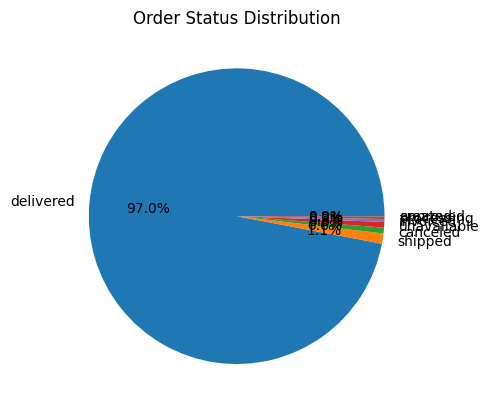

In [ ]:
# ==============================
# Sanjeevi Raman N
# Order Status Visualization
# ==============================

import matplotlib.pyplot as plt

order_status_counts = df['order_status'].value_counts()

plt.figure()
order_status_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Order Status Distribution")
plt.ylabel("")
plt.show()

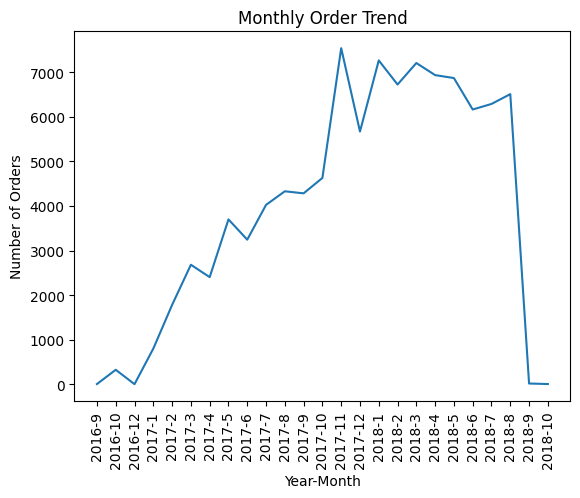

In [ ]:
# ==============================
# Vijay Sakthibalan P
# Monthly Orders Trend
# ==============================

# Ensure date columns are converted and new features are created
# This code is copied from cell IXC-R4FJBQeF to ensure dependencies are met.
import pandas as pd # Ensure pandas is imported if not already in scope, though it should be.
import matplotlib.pyplot as plt # Import matplotlib for plotting

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Create new useful features if they don't exist
if 'order_purchase_timestamp' in df.columns:
    if 'purchase_year' not in df.columns:
        df['purchase_year'] = df['order_purchase_timestamp'].dt.year
    if 'purchase_month' not in df.columns:
        df['purchase_month'] = df['order_purchase_timestamp'].dt.month

# Re-define monthly_orders_df to ensure its availability
monthly_orders = df.groupby(['purchase_year', 'purchase_month']).size()
monthly_orders_df = monthly_orders.reset_index(name='order_count')

monthly_orders_df['year_month'] = (
    monthly_orders_df['purchase_year'].astype(str)
    + "-"
    + monthly_orders_df['purchase_month'].astype(str)
)

plt.figure()
plt.plot(monthly_orders_df['year_month'], monthly_orders_df['order_count'])
plt.xticks(rotation=90)
plt.title("Monthly Order Trend")
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")
plt.show()

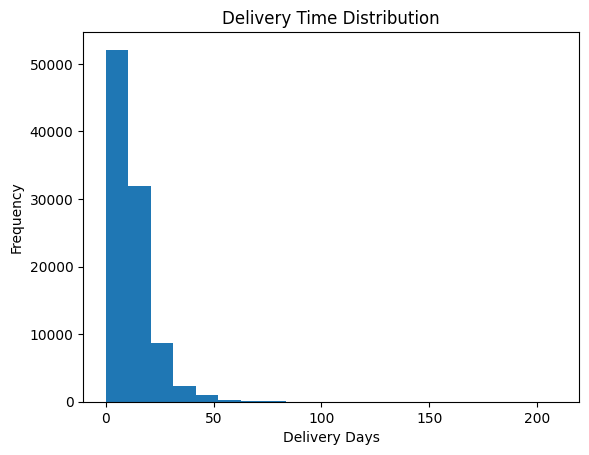

In [ ]:
# ==============================
# S Shaileshvar
# Delivery Time Distribution
# ==============================

plt.figure()
df['delivery_days'].dropna().plot(kind='hist', bins=20)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ==============================
# Vishwa S
# Advanced Metrics
# ==============================

# Ensure date columns are converted and 'delivery_days' is created
# This code is copied from cell IXC-R4FJBQeF and lQWIPadlElRE to ensure dependencies are met.
import pandas as pd

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Calculate actual delivery days if not already present
if 'delivery_days' not in df.columns:
    df['delivery_days'] = (
        df['order_delivered_customer_date'] - df['order_purchase_timestamp']
    ).dt.days

total_orders = df.shape[0]
avg_delivery = round(df['delivery_days'].mean(), 2)
late_deliveries = df[
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
].shape[0]

late_percentage = round((late_deliveries / total_orders) * 100, 2)

print("Total Orders:", total_orders)
print("Average Delivery Time:", avg_delivery, "days")
print("Late Deliveries:", late_deliveries)
print("Late Delivery Percentage:", late_percentage, "%")

Total Orders: 99441
Average Delivery Time: 12.09 days
Late Deliveries: 7827
Late Delivery Percentage: 7.87 %


In [ ]:
# ==============================
# Viswakailash H
# Master Business Insight
# ==============================

most_common_status = df['order_status'].value_counts().idxmax()

total_orders = df.shape[0]
avg_delivery = round(df['delivery_days'].mean(), 2)
late_deliveries = df[
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
].shape[0]

late_percentage = round((late_deliveries / total_orders) * 100, 2)

print("\n========== FINAL BUSINESS SUMMARY ==========")
print(f"Total Orders Processed: {total_orders}")
print(f"Most Frequent Order Status: {most_common_status}")
print(f"Average Delivery Time: {avg_delivery} days")
print(f"Late Delivery Rate: {late_percentage}%")

if late_percentage > 20:
    print("Insight: Delivery performance requires operational improvement.")
else:
    print("Insight: Delivery performance is within acceptable range.")

print("Monthly trend analysis indicates order volume variations across periods.")
print("============================================")


========== FINAL BUSINESS SUMMARY ==========
Total Orders Processed: 99441
Most Frequent Order Status: delivered
Average Delivery Time: 12.09 days
Late Delivery Rate: 7.87%
Insight: Delivery performance is within acceptable range.
Monthly trend analysis indicates order volume variations across periods.
